# Streaming Data Load (Leuschner SDR) - Test Data

Load raw per-dump `.npz` files from `data/lab04/streaming_test/<target>/` and
assemble them into arrays for analysis.

Each streaming file contains a single dump with keys:
- `corr00` -- auto-correlation pol 0, real float32 (1024 channels)
- `corr01` -- cross-correlation pol 0 x 1, complex64 (1024 channels)
- `corr11` -- auto-correlation pol 1, real float32 (1024 channels)
- `lo_freq_mhz` -- LO frequency (1420 or 1421 MHz)
- `noise_on` -- True for noise-diode calibration dumps, False for science
- `time` -- Unix timestamp (seconds, scalar)
- `target_name`, `alt_deg`, `az_deg`, `ra_deg`, `dec_deg` -- pointing
- `seq` -- sequence number within the observation

The first 64 dumps (32 per LO) are calibration dumps with the noise diode
ON.  The remaining dumps are science data with frequency switching
(LO alternating between 1420 and 1421 MHz).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# SDR / observation parameters
SAMPLE_RATE_HZ = 2.56e6
NFFT           = 1024
LO_ON_MHZ     = 1420.0
LO_OFF_MHZ    = 1421.0

%matplotlib inline
plt.rcParams.update({"figure.dpi": 130, "figure.facecolor": "white"})
print("Imports OK.")

Imports OK.


## 1. Discover and load all dumps

All dumps (calibration and science) live in the same target directory.
We sort by filename, load everything, then separate by the `noise_on` flag
and `lo_freq_mhz` value.

In [2]:
TARGET = 'gal_180_0'
DATA_DIR = Path(f"../../../data/lab04/streaming_test/{TARGET}")
dump_paths = sorted(DATA_DIR.glob(f"{TARGET}_dump_*.npz"))
N_dumps = len(dump_paths)
print(f"Found {N_dumps} dump files in {DATA_DIR}")

# Peek at first file for array dimensions
with np.load(dump_paths[0], allow_pickle=True) as first:
    N_CH = first["corr01"].shape[0]
    print(f"Channels per dump: {N_CH}")
    print(f"Keys: {list(first.keys())}")

# Pre-allocate
corr00_raw    = np.empty((N_dumps, N_CH), dtype=float)
corr01_raw    = np.empty((N_dumps, N_CH), dtype=complex)
corr11_raw    = np.empty((N_dumps, N_CH), dtype=float)
lo_mhz_arr    = np.empty(N_dumps, dtype=float)
noise_on_arr  = np.empty(N_dumps, dtype=bool)
unix_arr      = np.empty(N_dumps, dtype=float)
alt_deg_arr   = np.empty(N_dumps, dtype=float)
az_deg_arr    = np.empty(N_dumps, dtype=float)
ra_deg_arr    = np.empty(N_dumps, dtype=float)
dec_deg_arr   = np.empty(N_dumps, dtype=float)
seq_arr       = np.empty(N_dumps, dtype=int)

for i, path in enumerate(dump_paths):
    with np.load(path, allow_pickle=True) as npz:
        corr00_raw[i]  = npz["corr00"]
        corr01_raw[i]  = npz["corr01"]
        corr11_raw[i]  = npz["corr11"]
        lo_mhz_arr[i]  = float(npz["lo_freq_mhz"])
        noise_on_arr[i] = bool(npz["noise_on"])
        unix_arr[i]    = float(npz["time"])
        alt_deg_arr[i] = float(npz["alt_deg"])
        az_deg_arr[i]  = float(npz["az_deg"])
        ra_deg_arr[i]  = float(npz["ra_deg"])
        dec_deg_arr[i] = float(npz["dec_deg"])
        seq_arr[i]     = int(npz["seq"])
    if (i + 1) % 200 == 0:
        print(f"  loaded {i + 1}/{N_dumps}")

print(f"Loaded {N_dumps} dumps, shape = {corr01_raw.shape}")

# --- Separate calibration from science ---
cal_mask = noise_on_arr
sci_mask = ~noise_on_arr
N_cal = cal_mask.sum()
N_sci = sci_mask.sum()
print(f"\nCalibration dumps (noise ON): {N_cal}")
print(f"Science dumps (noise OFF):    {N_sci}")

# --- Separate ON and OFF by LO frequency (science only) ---
on_mask  = sci_mask & (lo_mhz_arr == LO_ON_MHZ)
off_mask = sci_mask & (lo_mhz_arr == LO_OFF_MHZ)
N_on  = on_mask.sum()
N_off = off_mask.sum()
print(f"  Science ON  (LO={LO_ON_MHZ} MHz): {N_on}")
print(f"  Science OFF (LO={LO_OFF_MHZ} MHz): {N_off}")

Found 2719 dump files in ../../../data/lab04/streaming_test/gal_180_0
Channels per dump: 1024
Keys: ['corr00', 'corr01', 'corr11', 'time', 'lo_freq_mhz', 'noise_on', 'target_name', 'alt_deg', 'az_deg', 'ra_deg', 'dec_deg', 'seq']
  loaded 200/2719
  loaded 400/2719
  loaded 600/2719
  loaded 800/2719
  loaded 1000/2719
  loaded 1200/2719
  loaded 1400/2719
  loaded 1600/2719
  loaded 1800/2719
  loaded 2000/2719
  loaded 2200/2719
  loaded 2400/2719
  loaded 2600/2719
Loaded 2719 dumps, shape = (2719, 1024)

Calibration dumps (noise ON): 64
Science dumps (noise OFF):    2655
  Science ON  (LO=1420.0 MHz): 1328
  Science OFF (LO=1421.0 MHz): 1327


## 1b. Extract noise diode calibration

The first dumps have the noise diode ON at both LO frequencies.
We separate them by LO to get calibration spectra at each frequency.

In [3]:
# --- Calibration dumps split by LO frequency ---
cal_on_mask  = cal_mask & (lo_mhz_arr == LO_ON_MHZ)
cal_off_mask = cal_mask & (lo_mhz_arr == LO_OFF_MHZ)

# Time-averaged calibration spectra (noise ON)
cal_corr00_on_mean  = np.nanmean(corr00_raw[cal_on_mask], axis=0)
cal_corr01_on_mean  = np.nanmean(corr01_raw[cal_on_mask], axis=0)
cal_corr11_on_mean  = np.nanmean(corr11_raw[cal_on_mask], axis=0)

cal_corr00_off_mean = np.nanmean(corr00_raw[cal_off_mask], axis=0)
cal_corr01_off_mean = np.nanmean(corr01_raw[cal_off_mask], axis=0)
cal_corr11_off_mean = np.nanmean(corr11_raw[cal_off_mask], axis=0)

print(f"Calibration at LO={LO_ON_MHZ} MHz:  {cal_on_mask.sum()} dumps")
print(f"Calibration at LO={LO_OFF_MHZ} MHz: {cal_off_mask.sum()} dumps")

Calibration at LO=1420.0 MHz:  32 dumps
Calibration at LO=1421.0 MHz: 32 dumps


## 1c. fftshift and mask LO DC bins

The FFT of complex I/Q data has channel ordering `[0, +df, ..., +fs/2, -fs/2, ..., -df]`.
We `fftshift` to reorder as `[-fs/2, ..., 0, ..., +fs/2]` so that the frequency
axis is monotonic and the baseband spans -1.28 to +1.28 MHz around the LO.

The DC bin (baseband 0 Hz = the LO frequency) has a large ADC offset spike.
We mask it to NaN.

In [4]:
# ---- fftshift all correlation products ----
corr00_raw = np.fft.fftshift(corr00_raw, axes=-1)
corr01_raw = np.fft.fftshift(corr01_raw, axes=-1)
corr11_raw = np.fft.fftshift(corr11_raw, axes=-1)

cal_corr00_on_mean  = np.fft.fftshift(cal_corr00_on_mean)
cal_corr01_on_mean  = np.fft.fftshift(cal_corr01_on_mean)
cal_corr11_on_mean  = np.fft.fftshift(cal_corr11_on_mean)
cal_corr00_off_mean = np.fft.fftshift(cal_corr00_off_mean)
cal_corr01_off_mean = np.fft.fftshift(cal_corr01_off_mean)
cal_corr11_off_mean = np.fft.fftshift(cal_corr11_off_mean)
print("Applied fftshift to all correlation products.")

# ---- Mask DC bin (LO frequency, center channel after fftshift) ----
DC_CHANNEL = N_CH // 2

print(f"DC bin at channel {DC_CHANNEL}: "
      f"corr00 = {np.nanmean(corr00_raw[:, DC_CHANNEL]):.0f}, "
      f"neighbours = {np.nanmean(corr00_raw[:, DC_CHANNEL-1]):.0f}, "
      f"{np.nanmean(corr00_raw[:, DC_CHANNEL+1]):.0f}")

for arr in [corr00_raw, corr01_raw, corr11_raw]:
    arr[:, DC_CHANNEL] = np.nan

for arr in [cal_corr00_on_mean, cal_corr01_on_mean, cal_corr11_on_mean,
            cal_corr00_off_mean, cal_corr01_off_mean, cal_corr11_off_mean]:
    arr[DC_CHANNEL] = np.nan

print(f"Masked channel {DC_CHANNEL} (DC/LO) to NaN.")

Applied fftshift to all correlation products.
DC bin at channel 512: corr00 = 809112, neighbours = 2822, 2752
Masked channel 512 (DC/LO) to NaN.


In [5]:
# ---- Frequency axis (baseband, fftshifted) ----
DF_HZ = SAMPLE_RATE_HZ / NFFT  # 2500 Hz per channel
F_BASEBAND_MHZ = np.fft.fftshift(np.fft.fftfreq(NFFT, d=1.0 / SAMPLE_RATE_HZ)) / 1e6
# Ranges from -1.28 to +1.2775 MHz

# Sky frequency: f_sky = LO + f_baseband
# ON band:  1420.0 + [-1.28, +1.28) = [1418.72, 1421.28) MHz
# OFF band: 1421.0 + [-1.28, +1.28) = [1419.72, 1422.28) MHz
# Overlap:  [1419.72, 1421.28) MHz -- HI at 1420.405 is in BOTH bands

# ---- Cadence (science dumps only) ----
sci_unix = unix_arr[sci_mask]
sci_dt = np.diff(sci_unix)
median_cadence = float(np.median(sci_dt))

# ---- Stokes parameters (science dumps only) ----
# I = corr00 + corr11  (total intensity)
# Q = corr00 - corr11
# U = 2 * Re(corr01)
# V = 2 * Im(corr01)
sci_corr00 = corr00_raw[sci_mask]
sci_corr01 = corr01_raw[sci_mask]
sci_corr11 = corr11_raw[sci_mask]

stokes_I = sci_corr00 + sci_corr11
stokes_Q = sci_corr00 - sci_corr11
stokes_U = 2.0 * sci_corr01.real
stokes_V = 2.0 * sci_corr01.imag

print(f"Baseband range: {F_BASEBAND_MHZ[0]:.3f} to {F_BASEBAND_MHZ[-1]:.3f} MHz")
print(f"Channels: {N_CH}, dnu = {DF_HZ:.0f} Hz = {DF_HZ/1e3:.2f} kHz")
print(f"Velocity resolution: dv = c*dnu/f = {3e5 * DF_HZ / (1420.405e6):.2f} km/s")
print(f"ON sky band:  {LO_ON_MHZ + F_BASEBAND_MHZ[0]:.2f} to {LO_ON_MHZ + F_BASEBAND_MHZ[-1]:.2f} MHz")
print(f"OFF sky band: {LO_OFF_MHZ + F_BASEBAND_MHZ[0]:.2f} to {LO_OFF_MHZ + F_BASEBAND_MHZ[-1]:.2f} MHz")
print(f"Median cadence (science): {median_cadence:.3f} s")
print(f"Time span: {(sci_unix[-1] - sci_unix[0]) / 3600:.2f} hours")

Baseband range: -1.280 to 1.278 MHz
Channels: 1024, dnu = 2500 Hz = 2.50 kHz
Velocity resolution: dv = c*dnu/f = 0.53 km/s
ON sky band:  1418.72 to 1421.28 MHz
OFF sky band: 1419.72 to 1422.28 MHz
Median cadence (science): 2.210 s
Time span: 1.63 hours


## 3. Frequency-switched bandpass removal

Divide ON by OFF to remove the instrumental bandpass shape. The sky
signal shifts by 1 MHz between the two LO settings, but the bandpass
(SDR + RF chain frequency response) stays fixed in channel space.

We pair consecutive ON/OFF dumps by index (they alternate 1:1) and
compute `ON / OFF` for Stokes I.

In [6]:
# ---- Pair ON and OFF science dumps ----
on_indices  = np.where(on_mask)[0]
off_indices = np.where(off_mask)[0]

# Pair by position: they alternate 1:1 in the science phase
n_pairs = min(len(on_indices), len(off_indices))
on_idx  = on_indices[:n_pairs]
off_idx = off_indices[:n_pairs]

# Stokes I for ON and OFF (index into full arrays, not sci-only)
I_on  = corr00_raw[on_idx] + corr11_raw[on_idx]    # (n_pairs, N_CH)
I_off = corr00_raw[off_idx] + corr11_raw[off_idx]   # (n_pairs, N_CH)

# Frequency-switched ratio: (ON - OFF) / OFF
# This isolates the spectral line signal from the bandpass
fs_ratio = (I_on - I_off) / I_off  # (n_pairs, N_CH)

# Timestamps for paired dumps (midpoint)
unix_paired = 0.5 * (unix_arr[on_idx] + unix_arr[off_idx])

print(f"Paired {n_pairs} ON/OFF dump pairs")
print(f"Frequency-switched ratio shape: {fs_ratio.shape}")

# Time-averaged frequency-switched spectrum
fs_mean = np.nanmean(fs_ratio, axis=0)
fs_std  = np.nanstd(fs_ratio, axis=0) / np.sqrt(n_pairs)

print(f"Mean ratio range: [{np.nanmin(fs_mean):.4f}, {np.nanmax(fs_mean):.4f}]")

Paired 1327 ON/OFF dump pairs
Frequency-switched ratio shape: (1327, 1024)
Mean ratio range: [-0.4655, 0.9362]


/tmp/ipykernel_357245/714568787.py:25: RuntimeWarning: Mean of empty slice
  fs_mean = np.nanmean(fs_ratio, axis=0)
/home/ikaros/projects/ay-121/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


## 4. Raw spectra and frequency-switched spectrum

/tmp/ipykernel_357245/3299353715.py:5: RuntimeWarning: Mean of empty slice
  I_on_mean  = np.nanmean(I_on, axis=0)
/tmp/ipykernel_357245/3299353715.py:6: RuntimeWarning: Mean of empty slice
  I_off_mean = np.nanmean(I_off, axis=0)
/tmp/ipykernel_357245/3299353715.py:15: RuntimeWarning: Mean of empty slice
  axes[1].plot(F_BASEBAND_MHZ, np.nanmean(corr00_raw[on_mask], axis=0),
/tmp/ipykernel_357245/3299353715.py:17: RuntimeWarning: Mean of empty slice
  axes[1].plot(F_BASEBAND_MHZ, np.nanmean(corr11_raw[on_mask], axis=0),
/tmp/ipykernel_357245/3299353715.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


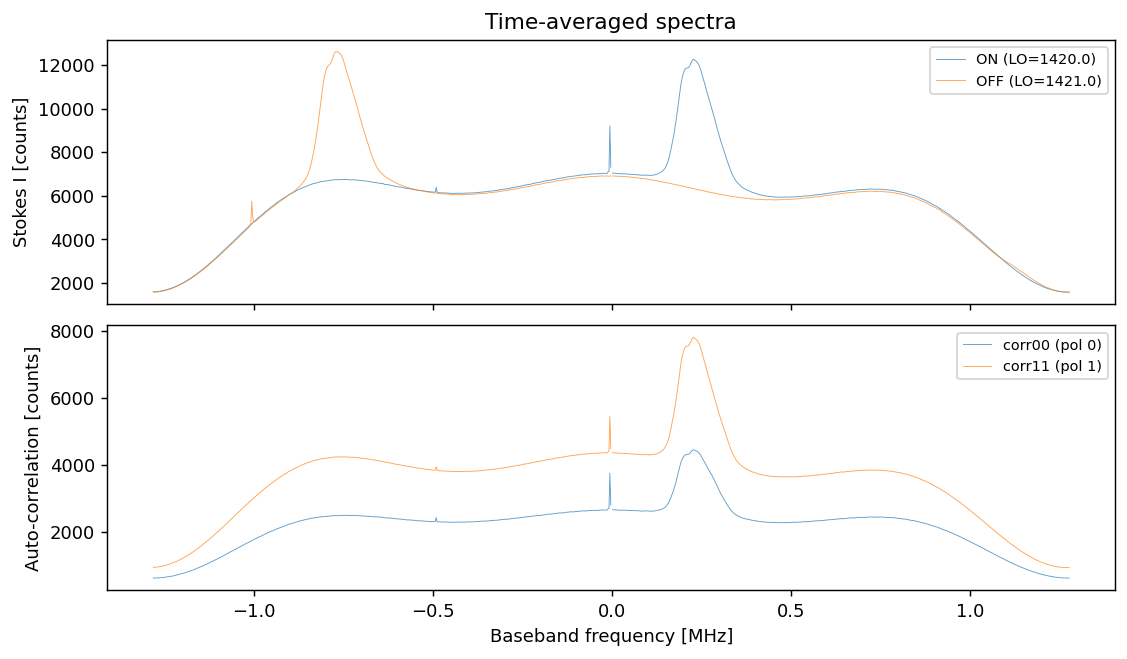

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(10, 5.5), sharex=True,
                         gridspec_kw={"hspace": 0.08})

# (a) Mean Stokes I -- ON and OFF
I_on_mean  = np.nanmean(I_on, axis=0)
I_off_mean = np.nanmean(I_off, axis=0)

axes[0].plot(F_BASEBAND_MHZ, I_on_mean, lw=0.5, alpha=0.7, label=f"ON (LO={LO_ON_MHZ})")
axes[0].plot(F_BASEBAND_MHZ, I_off_mean, lw=0.5, alpha=0.7, label=f"OFF (LO={LO_OFF_MHZ})")
axes[0].set_ylabel("Stokes I [counts]")
axes[0].set_title("Time-averaged spectra")
axes[0].legend(fontsize=8)

# (b) Mean auto-correlations (pol 0 and pol 1)
axes[1].plot(F_BASEBAND_MHZ, np.nanmean(corr00_raw[on_mask], axis=0),
             lw=0.5, alpha=0.7, label="corr00 (pol 0)")
axes[1].plot(F_BASEBAND_MHZ, np.nanmean(corr11_raw[on_mask], axis=0),
             lw=0.5, alpha=0.7, label="corr11 (pol 1)")
axes[1].set_ylabel("Auto-correlation [counts]")
axes[1].set_xlabel("Baseband frequency [MHz]")
axes[1].legend(fontsize=8)

fig.tight_layout()
plt.show()

## 4b. Frequency-switched spectrum near 1420.4 MHz

With complex I/Q sampling, each LO setting covers -1.28 to +1.28 MHz
around the LO.  HI at 1420.405 MHz falls in both bands:
- **ON** (LO=1420): baseband +0.405 MHz -- positive feature in (ON-OFF)/OFF
- **OFF** (LO=1421): baseband -0.595 MHz -- negative feature in (ON-OFF)/OFF

Mapping both to sky frequency, the positive and negative features should
coincide at 1420.405 MHz, producing the classic frequency-switched S-shape.

/tmp/ipykernel_357245/1354144140.py:9: RuntimeWarning: Mean of empty slice
  I_on_mean  = np.nanmean(I_on, axis=0)
/tmp/ipykernel_357245/1354144140.py:10: RuntimeWarning: Mean of empty slice
  I_off_mean = np.nanmean(I_off, axis=0)
/tmp/ipykernel_357245/1354144140.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


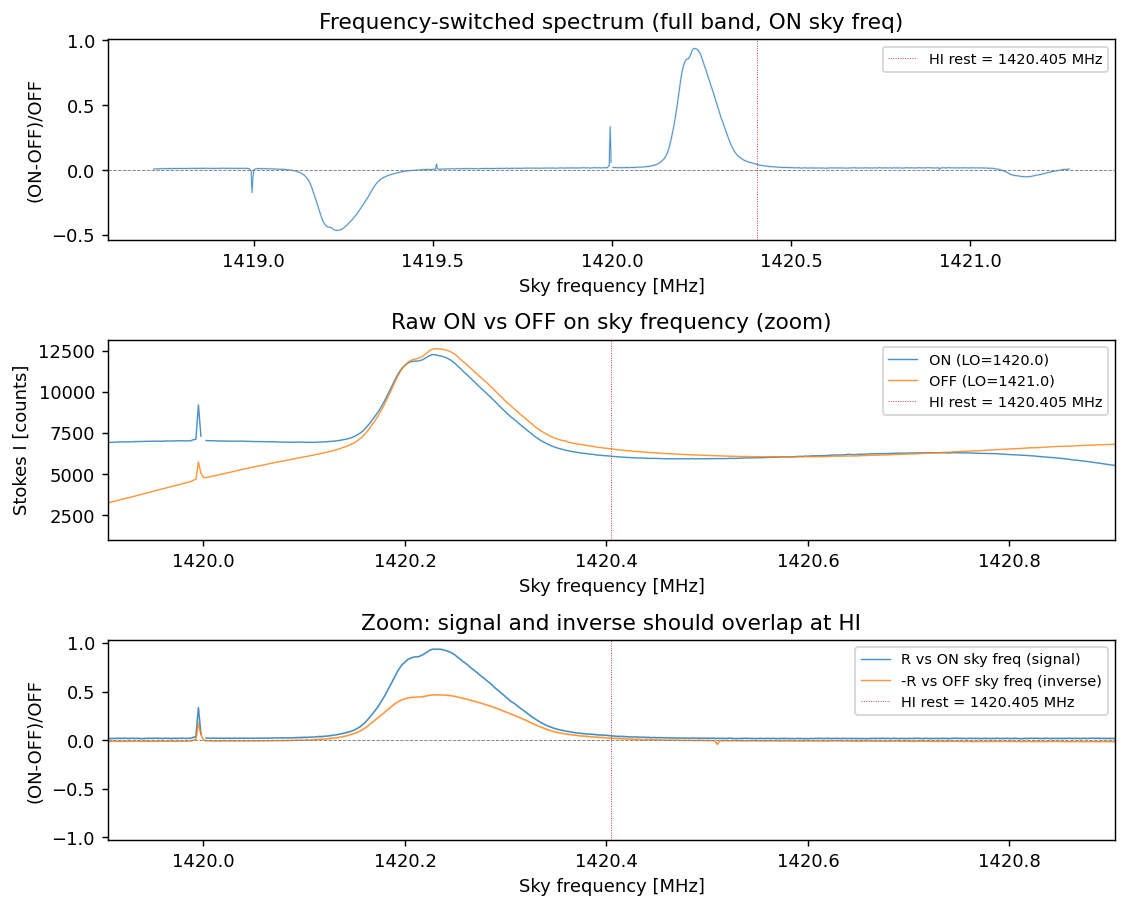

In [8]:
# Sky frequency axes (using corrected baseband)
F_SKY_ON_MHZ  = LO_ON_MHZ  + F_BASEBAND_MHZ   # [1418.72, 1421.28)
F_SKY_OFF_MHZ = LO_OFF_MHZ + F_BASEBAND_MHZ   # [1419.72, 1422.28)

HI_REST_MHZ = 1420.405
zoom_lo = HI_REST_MHZ - 0.5
zoom_hi = HI_REST_MHZ + 0.5

I_on_mean  = np.nanmean(I_on, axis=0)
I_off_mean = np.nanmean(I_off, axis=0)

fig, axes = plt.subplots(3, 1, figsize=(10, 8),
                         gridspec_kw={"hspace": 0.5})

# (a) Full-band switched spectrum on ON sky frequency
axes[0].plot(F_SKY_ON_MHZ, fs_mean, lw=0.5, color="C0", alpha=0.8)
axes[0].fill_between(F_SKY_ON_MHZ, fs_mean - fs_std, fs_mean + fs_std,
                     alpha=0.15, color="C0")
axes[0].axhline(0, color="gray", lw=0.5, ls="--")
axes[0].axvline(HI_REST_MHZ, color="C3", lw=0.5, ls=":",
                label=f"HI rest = {HI_REST_MHZ} MHz")
axes[0].set_ylabel("(ON-OFF)/OFF")
axes[0].set_xlabel("Sky frequency [MHz]")
axes[0].set_title("Frequency-switched spectrum (full band, ON sky freq)")
axes[0].ticklabel_format(axis="x", useOffset=False)
axes[0].legend(fontsize=8)

# (b) Zoom -- raw ON and OFF Stokes I on their sky frequencies
axes[1].plot(F_SKY_ON_MHZ, I_on_mean, lw=0.8, color="C0", alpha=0.8,
             label=f"ON (LO={LO_ON_MHZ})")
axes[1].plot(F_SKY_OFF_MHZ, I_off_mean, lw=0.8, color="C1", alpha=0.8,
             label=f"OFF (LO={LO_OFF_MHZ})")
axes[1].axvline(HI_REST_MHZ, color="C3", lw=0.5, ls=":",
                label=f"HI rest = {HI_REST_MHZ} MHz")
axes[1].set_xlim(zoom_lo, zoom_hi)
axes[1].set_ylabel("Stokes I [counts]")
axes[1].set_xlabel("Sky frequency [MHz]")
axes[1].set_title("Raw ON vs OFF on sky frequency (zoom)")
axes[1].ticklabel_format(axis="x", useOffset=False)
axes[1].legend(fontsize=8)

# (c) Zoom -- signal and inverse overlaid on sky frequency
axes[2].plot(F_SKY_ON_MHZ, fs_mean, lw=0.8, color="C0", alpha=0.8,
             label="R vs ON sky freq (signal)")
axes[2].fill_between(F_SKY_ON_MHZ, fs_mean - fs_std, fs_mean + fs_std,
                     alpha=0.15, color="C0")
axes[2].plot(F_SKY_OFF_MHZ, -fs_mean, lw=0.8, color="C1", alpha=0.8,
             label="-R vs OFF sky freq (inverse)")
axes[2].fill_between(F_SKY_OFF_MHZ, -fs_mean - fs_std, -fs_mean + fs_std,
                     alpha=0.15, color="C1")
axes[2].axhline(0, color="gray", lw=0.5, ls="--")
axes[2].axvline(HI_REST_MHZ, color="C3", lw=0.5, ls=":",
                label=f"HI rest = {HI_REST_MHZ} MHz")
axes[2].set_xlim(zoom_lo, zoom_hi)
axes[2].set_ylabel("(ON-OFF)/OFF")
axes[2].set_xlabel("Sky frequency [MHz]")
axes[2].set_title("Zoom: signal and inverse should overlap at HI")
axes[2].ticklabel_format(axis="x", useOffset=False)
axes[2].legend(fontsize=8)

fig.tight_layout()
plt.show()

## 5. Observation timeline and cadence

/tmp/ipykernel_357245/3739464350.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


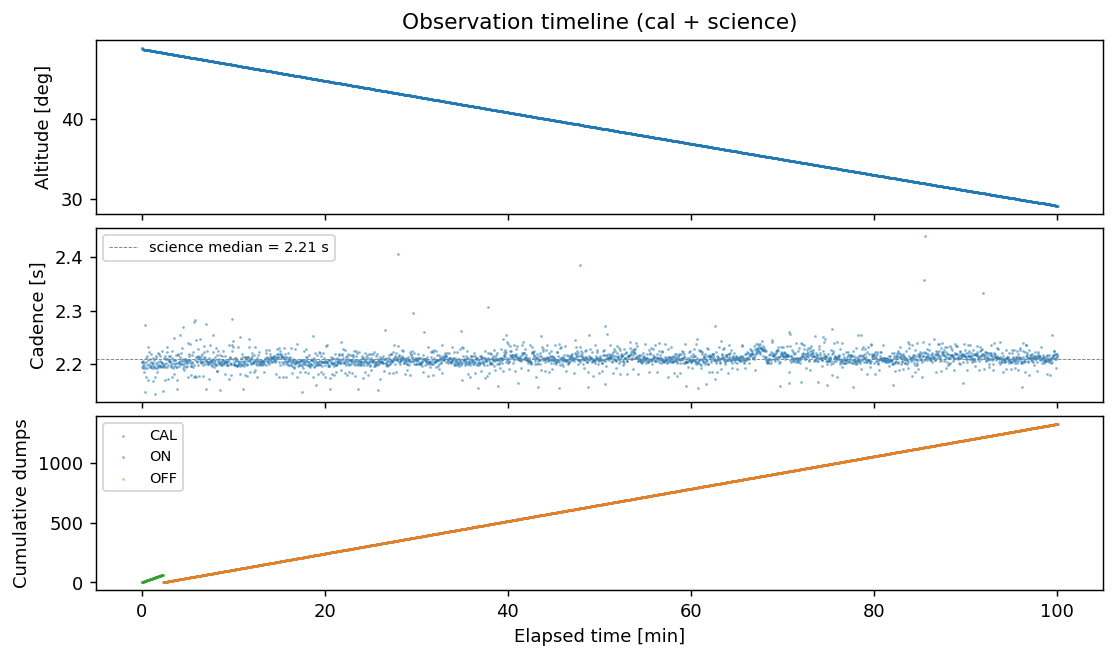

Total dumps:     2719 (64 cal + 1328 ON + 1327 OFF)
Median cadence:  2.210 s
Alt range:       29.2 to 48.9 deg


In [9]:
all_dt = np.diff(unix_arr)
elapsed_min = (unix_arr - unix_arr[0]) / 60.0

fig, axes = plt.subplots(3, 1, figsize=(10, 5.5), sharex=True,
                         gridspec_kw={"hspace": 0.08})

# (a) Altitude
axes[0].scatter(elapsed_min, alt_deg_arr, s=0.3, color="C0", alpha=0.5, rasterized=True)
axes[0].set_ylabel("Altitude [deg]")
axes[0].set_title("Observation timeline (cal + science)")

# (b) Inter-dump cadence
axes[1].scatter(elapsed_min[:-1], all_dt, s=0.3, color="C0", alpha=0.5, rasterized=True)
axes[1].set_ylabel("Cadence [s]")
axes[1].axhline(median_cadence, color="gray", lw=0.5, ls="--",
                label=f"science median = {median_cadence:.2f} s")
axes[1].legend(fontsize=8)

# (c) Cumulative dumps by type
cal_elapsed = elapsed_min[cal_mask]
on_elapsed  = elapsed_min[on_mask]
off_elapsed = elapsed_min[off_mask]

axes[2].scatter(cal_elapsed, np.arange(1, N_cal + 1),
                s=0.3, color="C2", alpha=0.5, label="CAL", rasterized=True)
axes[2].scatter(on_elapsed, np.cumsum(on_mask)[on_mask],
                s=0.3, color="C0", alpha=0.5, label="ON", rasterized=True)
axes[2].scatter(off_elapsed, np.cumsum(off_mask)[off_mask],
                s=0.3, color="C1", alpha=0.5, label="OFF", rasterized=True)
axes[2].set_ylabel("Cumulative dumps")
axes[2].set_xlabel("Elapsed time [min]")
axes[2].legend(fontsize=8)

fig.tight_layout()
plt.show()

print(f"Total dumps:     {N_dumps} ({N_cal} cal + {N_on} ON + {N_off} OFF)")
print(f"Median cadence:  {median_cadence:.3f} s")
print(f"Alt range:       {alt_deg_arr.min():.1f} to {alt_deg_arr.max():.1f} deg")

## 6. Duty cycle

The duty cycle is the fraction of wall-clock time spent integrating.
Each dump integrates `nblocks - 1` valid blocks of `nsamples / sample_rate`
seconds; the rest is overhead (USB transfer, FFT, correlation, disk I/O).

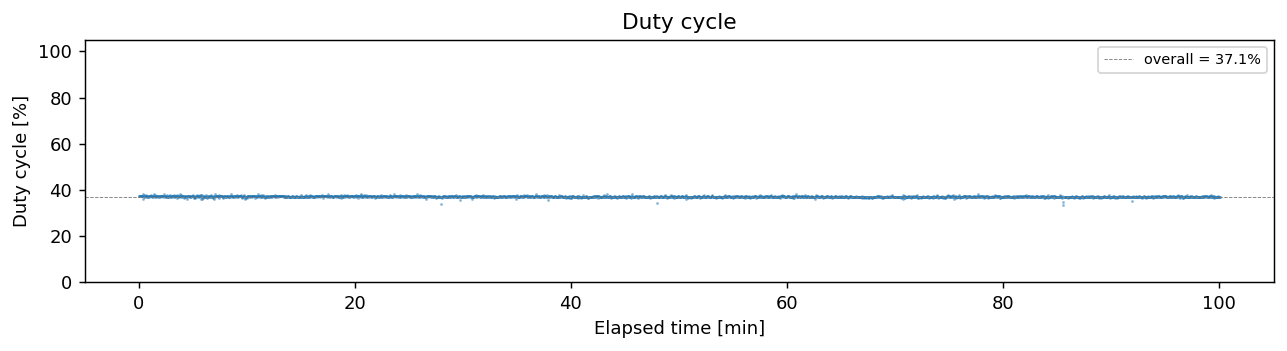

Valid blocks per dump:   64
Integration per dump:   0.819 s
Median cadence:         2.210 s
Overhead per dump:      1.391 s
Total integration time: 2227.4 s
Total wall-clock time:  6007.5 s
Overall duty cycle:     37.1%


In [10]:
NSAMPLES = 32768
NBLOCKS  = 65    # test data was collected with nblocks=65; block 0 discarded
NBLOCKS_VALID = NBLOCKS - 1

# Integration time per dump
t_int_per_dump = NBLOCKS_VALID * (NSAMPLES / SAMPLE_RATE_HZ)  # seconds

# Wall-clock cadence between consecutive dumps
wall_cadence = np.diff(unix_arr)

# Per-gap duty cycle
duty_per_gap = t_int_per_dump / wall_cadence

# Overall
total_int_time  = N_dumps * t_int_per_dump
total_wall_time = float(unix_arr[-1] - unix_arr[0])
overall_duty    = total_int_time / total_wall_time

fig, ax = plt.subplots(figsize=(10, 2.8))
ax.scatter(elapsed_min[:-1], duty_per_gap * 100, s=0.3, color="C0",
           alpha=0.5, rasterized=True)
ax.axhline(overall_duty * 100, color="gray", lw=0.5, ls="--",
           label=f"overall = {overall_duty * 100:.1f}%")
ax.set_ylabel("Duty cycle [%]")
ax.set_xlabel("Elapsed time [min]")
ax.set_ylim(0, 105)
ax.set_title("Duty cycle")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

print(f"Valid blocks per dump:   {NBLOCKS_VALID}")
print(f"Integration per dump:   {t_int_per_dump:.3f} s")
print(f"Median cadence:         {median_cadence:.3f} s")
print(f"Overhead per dump:      {median_cadence - t_int_per_dump:.3f} s")
print(f"Total integration time: {total_int_time:.1f} s")
print(f"Total wall-clock time:  {total_wall_time:.1f} s")
print(f"Overall duty cycle:     {overall_duty * 100:.1f}%")

## 7. Summary statistics

In [11]:
import datetime as _dt

t0 = _dt.datetime.fromtimestamp(unix_arr[0], tz=_dt.UTC)
t1 = _dt.datetime.fromtimestamp(unix_arr[-1], tz=_dt.UTC)

print(f"Observation start (UTC): {t0:%Y-%m-%d %H:%M:%S}")
print(f"Observation end   (UTC): {t1:%Y-%m-%d %H:%M:%S}")
print(f"Duration:                {total_wall_time / 60:.1f} min")
print(f"Total dumps:             {N_dumps} ({N_cal} cal + {N_on} ON + {N_off} OFF)")
print(f"Paired ON/OFF:           {n_pairs}")
print(f"Channels:                {N_CH} (dnu = {DF_HZ/1e3:.2f} kHz)")
print(f"LO frequencies:          {LO_ON_MHZ}, {LO_OFF_MHZ} MHz")
print(f"Median cadence:          {median_cadence:.3f} s")
print(f"Integration per dump:    {t_int_per_dump:.3f} s")
print(f"Duty cycle:              {overall_duty:.1%}")
print(f"Alt range:               {alt_deg_arr.min():.1f} to {alt_deg_arr.max():.1f} deg")
print(f"Target RA:               {ra_deg_arr[0]:.4f} deg")
print(f"Target Dec:              {dec_deg_arr[0]:.4f} deg")

Observation start (UTC): 2026-04-16 03:34:14
Observation end   (UTC): 2026-04-16 05:14:21
Duration:                100.1 min
Total dumps:             2719 (64 cal + 1328 ON + 1327 OFF)
Paired ON/OFF:           1327
Channels:                1024 (dnu = 2.50 kHz)
LO frequencies:          1420.0, 1421.0 MHz
Median cadence:          2.210 s
Integration per dump:    0.819 s
Duty cycle:              37.1%
Alt range:               29.2 to 48.9 deg
Target RA:               86.4050 deg
Target Dec:              28.9362 deg
